In [2]:
# import necessary libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

# Machine Learning Forecasting

## Objective

The objective of this notebook is to evaluate whether machine learning models can improve forecasting performance beyond traditional statistical approaches.

Previous analysis demonstrated that demand is primarily driven by strong seasonality and long-term growth. Statistical forecasting methods, particularly Holt-Winters Exponential Smoothing, achieved strong predictive performance and will serve as the benchmark for all machine learning models evaluated in this notebook.

The analysis will focus on:

- Feature engineering
- Lag and rolling-window features
- Temporal train/test validation
- Machine learning forecasting models
- Feature importance analysis
- Benchmark comparison against Holt-Winters

Success will be measured using out-of-sample forecasting accuracy, with particular emphasis on Mean Absolute Percentage Error (MAPE).

## Data Preparation

In [5]:
project_root = Path.cwd().parent
data_path = project_root / "data" / "processed" / "vw_forecasting_base.csv"
columns = [
    "month",
    "product_id",
    "market_id",
    "category",
    "brand",
    "lifecycle_stage",
    "region",
    "lead_time_months",
    "strategic_priority",
    "actual_demand_units",
    "promo_flag",
    "campaign_intensity",
    "demand_signal_quality",
    "available_supply_units",
    "production_capacity_units",
    "supply_constraint_flag",
    "actual_shipped_units",
    "unfulfilled_demand_units",
    "service_level_pct",
    "ending_inventory_units",
    "inventory_risk_status"
]
df = pd.read_csv(
    data_path,
    header=None,
    names=columns,
    sep=";",
    keep_default_na=False
)

In [6]:
# Display 5 first rows of the dataset
df.head()

,month,product_id,market_id,category,brand,lifecycle_stage,region,lead_time_months,strategic_priority,actual_demand_units,...,campaign_intensity,demand_signal_quality,available_supply_units,production_capacity_units,supply_constraint_flag,actual_shipped_units,unfulfilled_demand_units,service_level_pct,ending_inventory_units,inventory_risk_status
0,1/1/2021,PRD001,MKT001,Fragrance,Aurelian,Core,WE,1,3,1454,...,1.0,High,12250,19533,1,950,504,0.6534,1418,Normal
1,1/1/2021,PRD001,MKT002,Fragrance,Aurelian,Core,WE,1,5,1592,...,1.0,High,12250,19533,1,1128,464,0.7085,1172,Normal
2,1/1/2021,PRD001,MKT003,Fragrance,Aurelian,Core,WE,2,4,1536,...,1.0,High,12250,19533,1,1086,450,0.7070,1227,Normal
3,1/1/2021,PRD001,MKT004,Fragrance,Aurelian,Core,NA,2,4,1200,...,1.0,Medium,12250,19533,1,946,254,0.7883,1095,Normal
4,1/1/2021,PRD001,MKT005,Fragrance,Aurelian,Core,NA,3,2,843,...,1.0,High,12250,19533,1,720,123,0.8541,809,Normal


In [7]:
# Display shape of dataset
rows, cols = df.shape
print(f"Rows: {rows} | Columns: {cols}")

Rows: 17280 | Columns: 21


In [8]:
# Show basic summary statistics
df.describe()

,lead_time_months,strategic_priority,actual_demand_units,promo_flag,campaign_intensity,available_supply_units,production_capacity_units,supply_constraint_flag,actual_shipped_units,unfulfilled_demand_units,service_level_pct,ending_inventory_units
count,17280.000000,17280.000000,17280.000000,17280.000000,17280.000000,17280.00000,17280.000000,17280.000000,17280.000000,17280.000000,17280.000000,17280.000000
mean,2.666667,3.333333,1310.963600,0.127083,1.154167,15229.24375,17255.884722,0.430556,1140.506308,170.457292,4.797783,2482.983333
std,1.027432,1.433762,957.199488,0.333076,0.179656,8642.63890,10812.553231,0.495168,746.364198,303.961595,4.537714,2062.686166
min,1.000000,1.000000,0.000000,0.000000,1.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.368400,0.000000
25%,2.000000,2.000000,691.000000,0.000000,1.000000,9498.50000,10305.000000,0.000000,647.000000,0.000000,0.839775,1121.000000
50%,3.000000,4.000000,1108.000000,0.000000,1.100000,14307.00000,15982.500000,0.000000,1006.000000,37.000000,0.962800,1921.000000
75%,3.250000,4.250000,1691.000000,0.000000,1.225000,19475.75000,21796.750000,1.000000,1490.000000,218.000000,10.000000,3251.000000
max,4.000000,5.000000,11134.000000,1.000000,1.450000,74908.00000,111255.000000,1.000000,8264.000000,4159.000000,10.000000,16616.000000


In [9]:
# Convert 'month' column into datetime object
df["month"] = pd.to_datetime(df["month"], format="%d/%m/%Y", dayfirst=True)

In [10]:
# Check if conversion worked
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17280 entries, 0 to 17279
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   month                      17280 non-null  datetime64[ns]
 1   product_id                 17280 non-null  object        
 2   market_id                  17280 non-null  object        
 3   category                   17280 non-null  object        
 4   brand                      17280 non-null  object        
 5   lifecycle_stage            17280 non-null  object        
 6   region                     17280 non-null  object        
 7   lead_time_months           17280 non-null  int64         
 8   strategic_priority         17280 non-null  int64         
 9   actual_demand_units        17280 non-null  int64         
 10  promo_flag                 17280 non-null  int64         
 11  campaign_intensity         17280 non-null  float64       
 12  dema

## Feature Engineering

In [12]:
# Sort by product_id, market_id, month
df = df.sort_values(
    ["product_id", "market_id", "month"]
).reset_index(drop=True)

In [13]:
df.head()

,month,product_id,market_id,category,brand,lifecycle_stage,region,lead_time_months,strategic_priority,actual_demand_units,...,campaign_intensity,demand_signal_quality,available_supply_units,production_capacity_units,supply_constraint_flag,actual_shipped_units,unfulfilled_demand_units,service_level_pct,ending_inventory_units,inventory_risk_status
0,2021-01-01,PRD001,MKT001,Fragrance,Aurelian,Core,WE,1,3,1454,...,1.00,High,12250,19533,1,950,504,0.6534,1418,Normal
1,2021-02-01,PRD001,MKT001,Fragrance,Aurelian,Core,WE,1,3,1518,...,1.10,Medium,18847,17977,0,1352,166,0.8906,1711,Normal
2,2021-03-01,PRD001,MKT001,Fragrance,Aurelian,Core,WE,1,3,1579,...,1.10,Low,17757,19989,1,1393,186,0.8822,1662,Normal
3,2021-04-01,PRD001,MKT001,Fragrance,Aurelian,Core,WE,1,3,1413,...,1.00,Medium,18542,18876,0,1290,123,0.9130,1251,Normal
4,2021-05-01,PRD001,MKT001,Fragrance,Aurelian,Core,WE,1,3,1434,...,1.15,High,19256,20442,1,1360,74,0.9484,1310,Normal


In [14]:
# Create calendar features
df["year"] = df["month"].dt.year
df["month_number"] = df["month"].dt.month
df["quarter"] = df["month"].dt.quarter

In [26]:
# Lag features by product-market time series
df["lag_1"] = (
    df.groupby(["product_id", "market_id"])["actual_demand_units"]
      .shift(1)
)

df["lag_3"] = (
    df.groupby(["product_id", "market_id"])["actual_demand_units"]
      .shift(3)
)

df["lag_6"] = (
    df.groupby(["product_id", "market_id"])["actual_demand_units"]
      .shift(6)
)

df["lag_12"] = (
    df.groupby(["product_id", "market_id"])["actual_demand_units"]
      .shift(12)
)

In [30]:
# Create rolling features
df["rolling_mean_3"] = (
    df.groupby(["product_id", "market_id"])["actual_demand_units"]
      .transform(lambda x: x.shift(1).rolling(3).mean())
)

df["rolling_mean_6"] = (
    df.groupby(["product_id", "market_id"])["actual_demand_units"]
      .transform(lambda x: x.shift(1).rolling(6).mean())
)

In [32]:
# Add volatility features
df["rolling_std_3"] = (
    df.groupby(["product_id", "market_id"])["actual_demand_units"]
      .transform(lambda x: x.shift(1).rolling(3).std())
)

df["rolling_std_6"] = (
    df.groupby(["product_id", "market_id"])["actual_demand_units"]
      .transform(lambda x: x.shift(1).rolling(6).std())
)

In [34]:
df[
    [
        "actual_demand_units",
        "lag_1",
        "lag_3",
        "lag_6",
        "lag_12",
        "rolling_mean_3",
        "rolling_std_3"
    ]
].head(20)

,actual_demand_units,lag_1,lag_3,lag_6,lag_12,rolling_mean_3,rolling_std_3
0,1454,NaN,NaN,NaN,NaN,NaN,NaN
1,1518,1454.0,NaN,NaN,NaN,NaN,NaN
2,1579,1518.0,NaN,NaN,NaN,NaN,NaN
3,1413,1579.0,1454.0,NaN,NaN,1517.000000,62.506000
4,1434,1413.0,1518.0,NaN,NaN,1503.333333,83.966263
5,1353,1434.0,1579.0,NaN,NaN,1475.333333,90.389896
6,1380,1353.0,1413.0,1454.0,NaN,1400.000000,42.035699
7,1286,1380.0,1434.0,1518.0,NaN,1389.000000,41.243181
8,1526,1286.0,1353.0,1579.0,NaN,1339.666667,48.397658
9,1785,1526.0,1380.0,1413.0,NaN,1397.333333,120.935244


In [36]:
feature_cols = [
    "lag_1",
    "lag_3",
    "lag_6",
    "lag_12",
    "rolling_mean_3",
    "rolling_mean_6",
    "rolling_std_3",
    "rolling_std_6"
]

df[feature_cols].isna().sum()

lag_1              288
lag_3              864
lag_6             1728
lag_12            3456
rolling_mean_3     864
rolling_mean_6    1728
rolling_std_3      864
rolling_std_6     1728
dtype: int64

In [38]:
df.shape

(17280, 32)

In [40]:
df_model = df.dropna(
    subset=feature_cols
).copy()

In [42]:
print(df.shape)
print(df_model.shape)

(17280, 32)
(13824, 32)


## Categorical Feature Encoding

In [45]:
categorical_cols = [
    "product_id",
    "market_id",
    "category",
    "brand",
    "lifecycle_stage",
    "region",
    "demand_signal_quality",
    "inventory_risk_status"
]

df_model[categorical_cols].nunique()

product_id               24
market_id                12
category                  4
brand                     6
lifecycle_stage           3
region                    5
demand_signal_quality     3
inventory_risk_status     3
dtype: int64

In [47]:
df_model_encoded = pd.get_dummies(
    df_model,
    columns=categorical_cols,
    drop_first=True
)

In [49]:
print(df_model.shape)
print(df_model_encoded.shape)

(13824, 32)
(13824, 76)


In [51]:
target = "actual_demand_units"

In [75]:
cols_to_exclude = [
    "actual_demand_units",
    "month",

    # Leakage features
    "actual_shipped_units",
    "unfulfilled_demand_units",
    "service_level_pct"
]

feature_cols = [
    col
    for col in df_model_encoded.columns
    if col not in cols_to_exclude
]

X = df_model_encoded[feature_cols]
y = df_model_encoded[target]

In [77]:
train = df_model_encoded[
    df_model_encoded["month"] < "2025-01-01"
]

test = df_model_encoded[
    df_model_encoded["month"] >= "2025-01-01"
]

In [79]:
X_train = train[feature_cols]
y_train = train[target]

X_test = test[feature_cols]
y_test = test[target]

In [81]:
from sklearn.ensemble import RandomForestRegressor

In [83]:
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

In [85]:
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [87]:
rf_predictions = rf.predict(X_test)

In [89]:
rf_mae = mean_absolute_error(
    y_true=y_test,
    y_pred=rf_predictions
)

rf_mape = mean_absolute_percentage_error(
    y_true=y_test,
    y_pred=rf_predictions
)

print(f"RF MAE: {rf_mae:,.2f}")
print(f"RF MAPE: {rf_mape:.4f}")

RF MAE: 203.80
RF MAPE: 0.1271


In [91]:
feature_importance = (
    pd.DataFrame({
        "feature": X_train.columns,
        "importance": rf.feature_importances_
    })
    .sort_values("importance", ascending=False)
)

feature_importance.head(20)

,feature,importance
14,lag_12,0.821860
11,lag_1,0.070326
5,production_capacity_units,0.027757
15,rolling_mean_3,0.017364
16,rolling_mean_6,0.015217
2,promo_flag,0.014708
4,available_supply_units,0.007509
9,month_number,0.005118
13,lag_6,0.004398
12,lag_3,0.002933


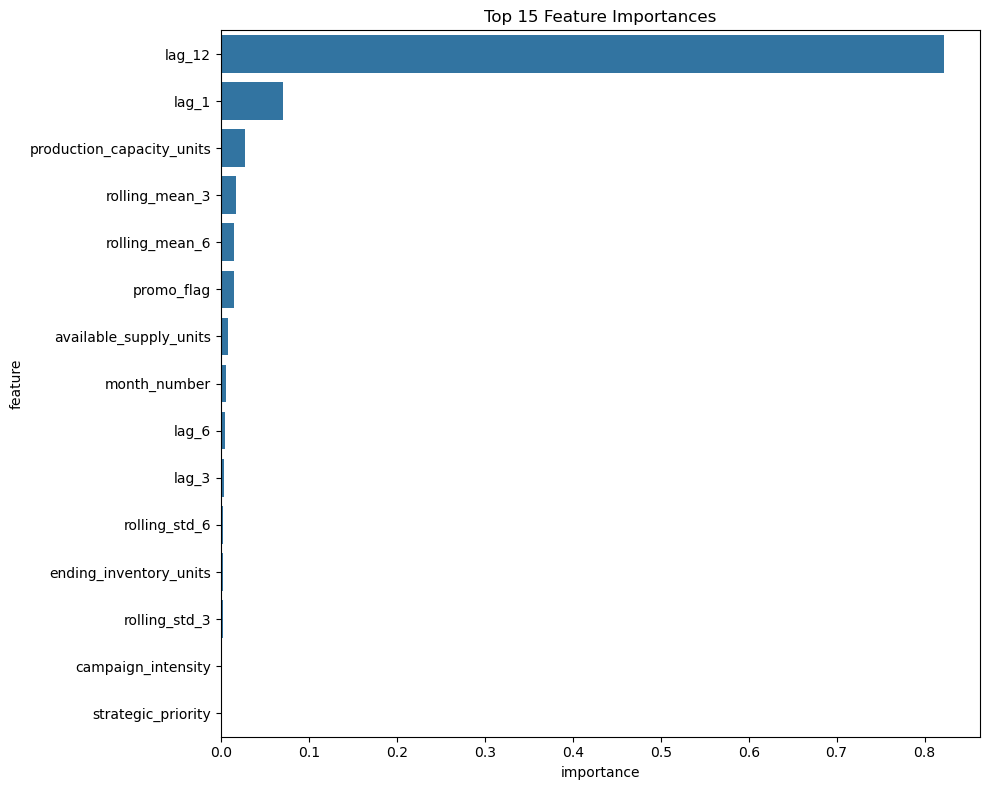

In [93]:
plt.figure(figsize=(10, 8))

sns.barplot(
    data=feature_importance.head(15),
    x="importance",
    y="feature"
)

plt.title("Top 15 Feature Importances")
plt.tight_layout()
plt.show()

## XGBoost Regressor

In [96]:
from xgboost import XGBRegressor

In [98]:
xgb = XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

In [100]:
xgb.fit(
    X_train,
    y_train
)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [104]:
xgb_predictions = xgb.predict(X_test)

In [106]:
xgb_mae = mean_absolute_error(
    y_true=y_test,
    y_pred=xgb_predictions
)

xgb_mape = mean_absolute_percentage_error(
    y_true=y_test,
    y_pred=xgb_predictions
)

print(f"XGB MAE: {xgb_mae:,.2f}")
print(f"XGB MAPE: {xgb_mape:.4f}")

XGB MAE: 188.00
XGB MAPE: 0.1158


In [108]:
xgb_feature_importance = (
    pd.DataFrame({
        "feature": X_train.columns,
        "importance": xgb.feature_importances_
    })
    .sort_values("importance", ascending=False)
)

xgb_feature_importance.head(15)

,feature,importance
14,lag_12,0.457995
11,lag_1,0.094994
2,promo_flag,0.037082
5,production_capacity_units,0.036544
9,month_number,0.033374
16,rolling_mean_6,0.026097
15,rolling_mean_3,0.024779
3,campaign_intensity,0.016595
55,category_Skincare,0.012819
53,category_Fragrance,0.012741


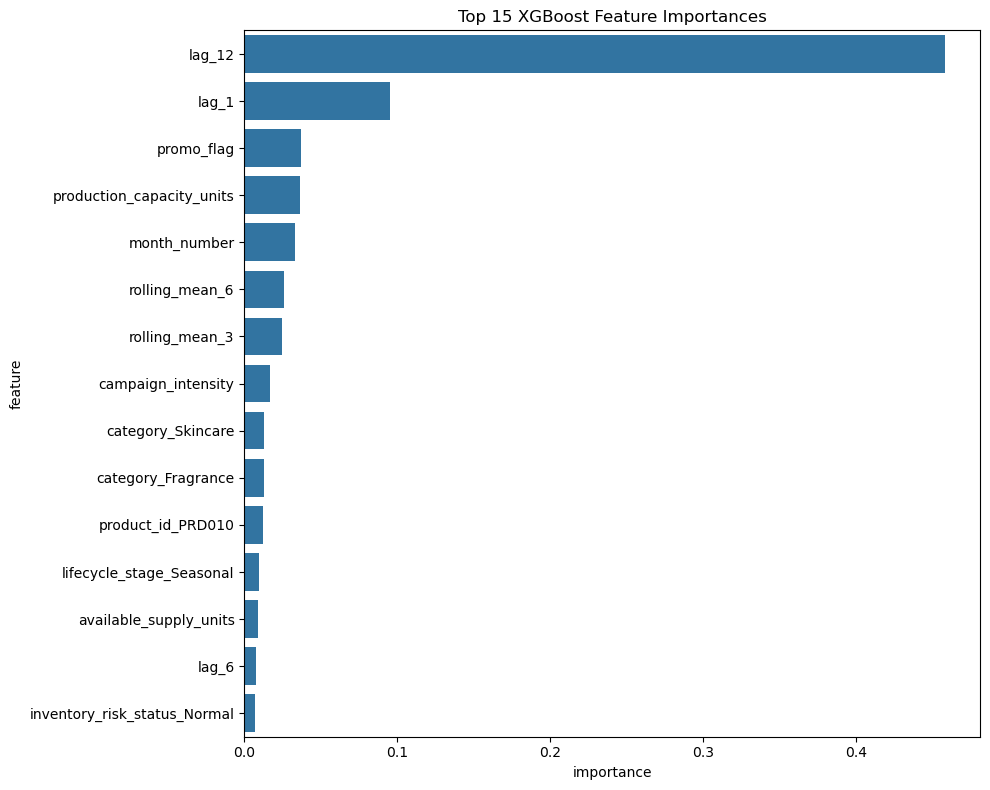

In [110]:
plt.figure(figsize=(10, 8))

sns.barplot(
    data=xgb_feature_importance.head(15),
    x="importance",
    y="feature"
)

plt.title("Top 15 XGBoost Feature Importances")
plt.tight_layout()
plt.show()